In [ ]:
# # # In colab, uncomment
# %%bash

# set -euo pipefail

# BASE_URL="https://raw.githubusercontent.com/Inkln/CV-HSE-MIPT-Course-2026-spring/refs/heads/main/lesson_9"
# REPO_URL="https://github.com/Inkln/CV-HSE-MIPT-Course-2026-spring.git"

# FILES=(
#   ".python-version"
#   "pyproject.toml"
#   "uv.lock"
# )

# for file in "${FILES[@]}"; do
#   echo "Downloading $file..."
#   curl -fsSL -o "$file" "$BASE_URL/$file"
# done

# if ! command -v uv >/dev/null 2>&1; then
#   echo "Error: uv is not installed or not in PATH." >&2
#   exit 1
# fi

# echo "Installing dependencies into the global Python environment..."
# uv sync --locked --system

# # Download assets folder using sparse checkout
# echo "Downloading assets folder..."
# TMP_DIR="$(mktemp -d)"

# git clone --depth=1 --filter=blob:none --sparse "$REPO_URL" "$TMP_DIR"
# cd "$TMP_DIR"
# git sparse-checkout set "$SUBDIR/assets"

# cd - >/dev/null
# mkdir -p assets
# cp -r "$TMP_DIR/$SUBDIR/assets/"* ./assets/

# rm -rf "$TMP_DIR"

# echo "Done."

# Лекция: Компьютерное зрение
## Generative modeling: Autoregressive models & Normalizing Flow

**Преподаватель:** Весельев Александр, Т-Банк

**Аудитория:** ФКН ВШЭ, МФТИ

---

## Содержание

1. Метрики
   1. FID (Fréchet inception distance)
   2. Inception Score
   3. Precision & Recall
   4. Aesthetic Score
   5. Text2Image Assessment
      1. CLIP Score
      2. Wise
      3. Q-Sit, DeQA
      4. Image Arena
2. Autoregressive
   1. Постановка задачи
   2. PixelCNN архитектура
   3. VAR
   4. Switti
   5. Обзор современных моделей (2026)
3. Normalizing Flow
   1. Постановка задачи. CoV
   2. Примеры Normalizing Flow
      1. Linear Normalizing Flows
      2. RealNVP, (GLOW)
      3. CNF (Continuous Normalizing Flows)

---

# Метрики

## 1. FID (Fréchet Inception Distance)

Метрика для оценки качества сгенерированных изображений

$$FID = \|\mu - \mu_w\|^2 + tr(\Sigma + \Sigma_w - 2(\Sigma \Sigma_w)^{\frac{1}{2}})$$

$\mathcal{N}(\mu, \Sigma)$ — это многомерное нормальное распределение, оценённое по признакам модели [Inception v3](https://arxiv.org/pdf/1512.00567), вычисленным на реальных изображениях, а $\mathcal{N}(\mu_w, \Sigma_w)$ — это многомерное нормальное распределение, оценённое по признакам Inception v3, вычисленным на сгенерированных (фейковых) изображениях.

По сути является 2 Wasserstein distance.

In [1]:
# source https://github.com/Lightning-AI/torchmetrics/blob/master/src/torchmetrics/image/fid.py
import torch

from torch import Tensor
from torch_fidelity.feature_extractor_inceptionv3 import FeatureExtractorInceptionV3


def compute_fid(mu1: Tensor, sigma1: Tensor, mu2: Tensor, sigma2: Tensor) -> Tensor:
    r"""Compute adjusted version of `Fid Score`_.

    The Frechet Inception Distance between two multivariate Gaussians X_x ~ N(mu_1, sigm_1)
    and X_y ~ N(mu_2, sigm_2) is d^2 = ||mu_1 - mu_2||^2 + Tr(sigm_1 + sigm_2 - 2*sqrt(sigm_1*sigm_2)).

    Args:
        mu1: mean of activations calculated on predicted (x) samples
        sigma1: covariance matrix over activations calculated on predicted (x) samples
        mu2: mean of activations calculated on target (y) samples
        sigma2: covariance matrix over activations calculated on target (y) samples

    Returns:
        Scalar value of the distance between sets.

    """
    a = (mu1 - mu2).square().sum(dim=-1)
    b = sigma1.trace() + sigma2.trace()
    c = torch.linalg.eigvals(sigma1 @ sigma2).sqrt().real.sum(dim=-1)

    return a + b - 2 * c


class FrechetInceptionDistance:
    def __init__(self) -> None:
        self.normalize = False
        self.antialias = True
        self.num_features = 2048

        self.inception = FeatureExtractorInceptionV3(
            name="inception-v3-compat",
            features_list=[str(self.num_features)],
            feature_extractor_weights_path=None,
            antialias=self.antialias,
        )

        self.mx_num_feats = (self.num_features, self.num_features)
        
        self.real_features_sum = torch.zeros(self.num_features).double()
        self.real_features_cov_sum = torch.zeros(self.mx_num_feats).double()
        self.real_features_num_samples = torch.tensor(0).long()

        self.fake_features_sum = torch.zeros(self.num_features).double()
        self.fake_features_cov_sum = torch.zeros(self.mx_num_feats).double() 
        self.fake_features_num_samples = torch.tensor(0).long()

    def update(self, imgs: Tensor, real: bool) -> None:
        """Update the state with extracted features.

        Args:
            imgs: Input img tensors to evaluate. If used custom feature extractor please
                make sure dtype and size is correct for the model.
            real: Whether given image is real or fake.

        """
        imgs = (imgs * 255).byte() if self.normalize else imgs
        features = self.inception(imgs)[0]
        self.orig_dtype = features.dtype
        features = features.double()

        if features.dim() == 1:
            features = features.unsqueeze(0)
        if real:
            self.real_features_sum += features.sum(dim=0)
            self.real_features_cov_sum += features.t().mm(features)
            self.real_features_num_samples += imgs.shape[0]
        else:
            self.fake_features_sum += features.sum(dim=0)
            self.fake_features_cov_sum += features.t().mm(features)
            self.fake_features_num_samples += imgs.shape[0]

    def compute(self) -> Tensor:
        """Calculate FID score based on accumulated extracted features from the two distributions."""
        if self.real_features_num_samples < 2 or self.fake_features_num_samples < 2:
            raise RuntimeError("More than one sample is required for both the real and fake distributed to compute FID")
        mean_real = (self.real_features_sum / self.real_features_num_samples).unsqueeze(0)
        mean_fake = (self.fake_features_sum / self.fake_features_num_samples).unsqueeze(0)

        cov_real_num = self.real_features_cov_sum - self.real_features_num_samples * mean_real.t().mm(mean_real)
        cov_real = cov_real_num / (self.real_features_num_samples - 1)
        cov_fake_num = self.fake_features_cov_sum - self.fake_features_num_samples * mean_fake.t().mm(mean_fake)
        cov_fake = cov_fake_num / (self.fake_features_num_samples - 1)
        return compute_fid(mean_real.squeeze(0), cov_real, mean_fake.squeeze(0), cov_fake).to(self.orig_dtype)

    def reset(self) -> None:
        """Reset metric states."""
        self.real_features_sum = torch.zeros(self.num_features).double()
        self.real_features_cov_sum = torch.zeros(self.mx_num_feats).double()
        self.real_features_num_samples = torch.tensor(0).long()

        self.fake_features_sum = torch.zeros(self.num_features).double()
        self.fake_features_cov_sum = torch.zeros(self.mx_num_feats).double() 
        self.fake_features_num_samples = torch.tensor(0).long()


########
fid = FrechetInceptionDistance()

imgs_dist1 = torch.randint(0, 200, (50, 3, 299, 299), dtype=torch.uint8)
imgs_dist2 = torch.randint(100, 255, (50, 3, 299, 299), dtype=torch.uint8)

fid.update(imgs_dist1, real=True)
fid.update(imgs_dist2, real=False)
fid.compute()

tensor(23.9406)

## 2. IS (Inception Score)

$$IS = exp(\mathbb{E}_x KL(p(y | x ) || p(y)))$$

где:

* $p(y|x)$ -  распределение классов для одного изображения
* $p(y)$ - среднее распределение по всем изображениям

Идея:
- Насколько изображение понятное
- Насколько разнообразны изображения



In [2]:
# source: https://github.com/Lightning-AI/torchmetrics/blob/master/src/torchmetrics/image/inception.py

def dim_zero_cat(x: Tensor | list[Tensor]) -> Tensor:
    """Concatenation along the zero dimension."""
    if isinstance(x, torch.Tensor):
        return x
    x = [y.unsqueeze(0) if y.numel() == 1 and y.ndim == 0 else y for y in x]
    if not x:  # empty list
        raise ValueError("No samples to concatenate")
    return torch.cat(x, dim=0)


class InceptionScore:
    def __init__(
        self,
        feature: str = "logits_unbiased",
        splits: int = 10,
        normalize: bool = False,
    ) -> None:
        self.inception = FeatureExtractorInceptionV3(name="inception-v3-compat", features_list=[str(feature)])
        self.normalize = normalize
        self.splits = splits

        self.features: list[Tensor] = []

    def update(self, imgs: Tensor) -> None:
        """Update the state with extracted features."""
        imgs = (imgs * 255).byte() if self.normalize else imgs
        features = self.inception(imgs)[0]
        self.features.append(features)

    def compute(self) -> tuple[Tensor, Tensor]:
        """Compute metric."""
        features = dim_zero_cat(self.features)
        # random permute the features
        idx = torch.randperm(features.shape[0])
        features = features[idx]

        # calculate probs and logits
        prob = features.softmax(dim=1)
        log_prob = features.log_softmax(dim=1)

        # split into groups
        prob = prob.chunk(self.splits, dim=0)
        log_prob = log_prob.chunk(self.splits, dim=0)

        # calculate score per split
        mean_prob = [p.mean(dim=0, keepdim=True) for p in prob]
        kl_ = [p * (log_p - m_p.log()) for p, log_p, m_p in zip(prob, log_prob, mean_prob)]
        kl_ = [k.sum(dim=1).mean().exp() for k in kl_]
        kl = torch.stack(kl_)

        # return mean and std
        return kl.mean(), kl.std()

In [3]:
inception = InceptionScore()
imgs = torch.randint(0, 255, (100, 3, 299, 299), dtype=torch.uint8)

inception.update(imgs)
inception.compute()

(tensor(1.0530), tensor(0.0119))

## 3. Precision and Recall

![precision-recall](./assets/precision-recall.png)

In [4]:
# adapted from https://github.com/toshas/torch-fidelity

def _cdist_part(features_1, features_2, batch_size=10000):
    """Row-batched pairwise L2 distances (features_1 rows vs all of features_2)."""
    dists = []
    for feat2_batch in features_2.split(batch_size):
        dists.append(torch.cdist(features_1, feat2_batch).cpu())
    return torch.cat(dists, dim=1)


def _cdist_full(features_1, features_2, batch_size=10000):
    """Full pairwise L2 distance matrix, computed in blocks to limit GPU memory."""
    dists = []
    for feat1_batch in features_1.split(batch_size):
        dists_batch = []
        for feat2_batch in features_2.split(batch_size):
            dists_batch.append(torch.cdist(feat1_batch, feat2_batch).cpu())
        dists.append(torch.cat(dists_batch, dim=1))
    return torch.cat(dists, dim=0)


# faster, more RAM
def _precision_recall_full(features_1, features_2, neighborhood=3, batch_size=10000):
    dist_nn_1 = _cdist_full(features_1, features_1, batch_size).kthvalue(neighborhood + 1).values
    dist_nn_2 = _cdist_full(features_2, features_2, batch_size).kthvalue(neighborhood + 1).values
    dist_2_1 = _cdist_full(features_2, features_1, batch_size)
    dist_1_2 = dist_2_1.T
    recall = (dist_2_1 <= dist_nn_1).any(dim=1).float().mean().item()
    precision = (dist_1_2 <= dist_nn_2).any(dim=1).float().mean().item()
    return precision, recall


# slower, less RAM
def _precision_recall_part(features_1, features_2, neighborhood=3, batch_size=10000):
    # Recall: for each real sample, is it inside any generated sample's ball?
    dist_nn_1 = []
    for feat_1_batch in features_1.split(batch_size):
        dist_nn_1.append(_cdist_part(feat_1_batch, features_1, batch_size).kthvalue(neighborhood + 1).values)
    dist_nn_1 = torch.cat(dist_nn_1)
    recall = []
    for feat_2_batch in features_2.split(batch_size):
        dist_2_1_batch = _cdist_part(feat_2_batch, features_1, batch_size)
        recall.append((dist_2_1_batch <= dist_nn_1).any(dim=1).float())
    recall = torch.cat(recall).mean().item()
    # Precision: for each generated sample, is it inside any real sample's ball?
    dist_nn_2 = []
    for feat_2_batch in features_2.split(batch_size):
        dist_nn_2.append(_cdist_part(feat_2_batch, features_2, batch_size).kthvalue(neighborhood + 1).values)
    dist_nn_2 = torch.cat(dist_nn_2)
    precision = []
    for feat_1_batch in features_1.split(batch_size):
        dist_1_2_batch = _cdist_part(feat_1_batch, features_2, batch_size)
        precision.append((dist_1_2_batch <= dist_nn_2).any(dim=1).float())
    precision = torch.cat(precision).mean().item()
    return precision, recall


def precision_recall(features_generated, features_real, neighborhood=3, batch_size=10000, save_cpu_ram=False):
    """
    Compute Precision, Recall, and F-score between two sets of feature vectors.

    Args:
        features_generated: Tensor (N, D) — generated sample features.
        features_real:      Tensor (M, D) — real sample features.
        neighborhood:       Number of nearest neighbors for manifold estimation (default 3).
        batch_size:         Block size for batched distance computation (default 10000).
        save_cpu_ram:       If True, use a slower but more memory-efficient algorithm.

    Returns:
        (precision, recall, f_score) — all floats in [0, 1].
    """
    assert features_generated.dim() == 2 and features_real.dim() == 2
    assert features_generated.shape[1] == features_real.shape[1]

    fn = _precision_recall_part if save_cpu_ram else _precision_recall_full
    precision, recall = fn(features_generated, features_real, neighborhood, batch_size)
    f_score = 2 * precision * recall / max(1e-5, precision + recall)
    return precision, recall, f_score


features_generated = torch.randn(1000, 100)
features_real = torch.randn(500, 100)

precision, recall, f_score = precision_recall(features_generated, features_real)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F-score: {f_score:.4f}")

Precision: 0.5680
Recall: 0.5960
F-score: 0.5817


# 4. Aesthetic predictor

[LAION](https://laion.ai/projects/)

*Идея*
- Взять `CLIP` (в целом, можно любую другую модель, которая делает хорошие эмбеды)
- Разметить большой датасет картинок (насколько они красивы)
- Обучить голову (либо всю модель)
- Получить предиктор "красоты"

[aesthetic-predictor git](https://github.com/LAION-AI/aesthetic-predictor)

*Где оригинально применялось*
- Фильтрация датасета

In [5]:
import truststore

truststore.inject_into_ssl()

In [6]:
import os
import torch
import torch.nn as nn
import open_clip

from os.path import expanduser
from urllib.request import urlretrieve

from PIL import Image

from safetensors.torch import load_file
from pathlib import Path
from huggingface_hub import hf_hub_download


REPO_ID = "timm/vit_large_patch14_clip_224.openai"
FILENAME = "open_clip_model.safetensors"
LOCAL_DIR = Path("./.weights/")
WEIGHTS_PATH = LOCAL_DIR / FILENAME

LOCAL_DIR.mkdir(parents=True, exist_ok=True)

if not WEIGHTS_PATH.exists():
    downloaded_path = hf_hub_download(
        repo_id=REPO_ID,
        filename=FILENAME,
        local_dir=LOCAL_DIR,
        local_dir_use_symlinks=False,
    )

    print(f"Downloaded to: {downloaded_path}")


checkpoint = load_file(str(WEIGHTS_PATH))

def get_aesthetic_model(clip_model="vit_l_14"):
    """load the aethetic model"""
    home = expanduser("~")
    cache_folder = home + "/.cache/emb_reader"
    path_to_model = cache_folder + "/sa_0_4_"+clip_model+"_linear.pth"
    if not os.path.exists(path_to_model):
        os.makedirs(cache_folder, exist_ok=True)
        url_model = (
            "https://github.com/LAION-AI/aesthetic-predictor/blob/main/sa_0_4_"+clip_model+"_linear.pth?raw=true"
        )
        urlretrieve(url_model, path_to_model)
    if clip_model == "vit_l_14":
        m = nn.Linear(768, 1)
    elif clip_model == "vit_b_32":
        m = nn.Linear(512, 1)
    else:
        raise ValueError()
    s = torch.load(path_to_model)
    m.load_state_dict(s)
    m.eval()
    return m


amodel= get_aesthetic_model(clip_model="vit_l_14")
amodel.eval()

model, _, preprocess = open_clip.create_model_and_transforms('ViT-L-14', pretrained=None)
model.load_state_dict(checkpoint)

model.eval();

Aesthetic score: 4.273191928863525


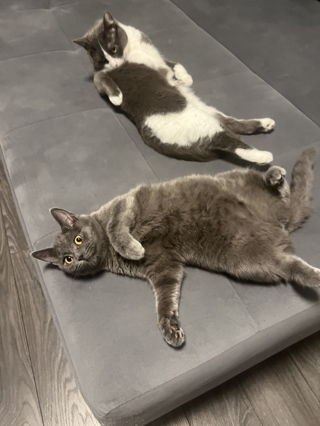

In [7]:
image_pil = Image.open("assets/cats.jpg")

image = preprocess(image_pil).unsqueeze(0)
with torch.no_grad():
    image_features = model.encode_image(image)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    prediction = amodel(image_features)
    print(f"Aesthetic score: {prediction.item()}")

image_pil.resize((image_pil.size[0] // 3, image_pil.size[1] // 3))

## 5. Text 2 Image Assessment

### 1. CLIP Score

Думаю, здесь все понятно

### 2. Wise

[Github](https://github.com/PKU-YuanGroup/WISE)

Один из примеров концепции "сложных бенчмарков" -- делаем сложный запрос, который должна обработать модель, а затем анализируем полученный результат с помощью больших моделей (например, GPT-4).

### 3. Q-Sit, DeQA-score

- [Q-sit git](https://github.com/zzc-1998/Q-SiT)
- [DeQA git](https://github.com/zhiyuanyou/DeQA-Score)

Концепция дообучения vlm моделей под задачу IQA (Image quality assessment). Может оценивать как Image-Text пары, так и standalone image примеры

### 4. VLM-AAJ

Оценка через запрос к большой модели с просьбой аналитики. Можно разделить на standalone и sbs (side-by-side) оценки

### 5. Опросы людей

Самый хороший сигнал (особенно, если опрашиваем ЦА), однако самый дорогой

### 6. Image Arena

Опенсорс (и не только) платформы для оценки изображений (и не только) пользователями. Рейтинг составляется на основе Elo rating

[Пример арены](https://huggingface.co/spaces/ArtificialAnalysis/Text-to-Image-Leaderboard)

In [13]:
# VLM-AAJ SBS
import os
import io
import json
import base64
from typing import Literal, Optional, Dict, Any

import requests
from PIL import Image


OpenRouterWinner = Literal["A", "B"]


class OpenRouterVLMJudgeError(Exception):
    pass


def pil_to_data_url(image: Image.Image, format: str = "PNG") -> str:
    """
    Convert PIL.Image to data URL suitable for OpenRouter image input.
    """
    buffer = io.BytesIO()

    image.save(buffer, format=format)
    image_bytes = buffer.getvalue()

    mime = "image/png" if format.upper() == "PNG" else f"image/{format.lower()}"
    b64 = base64.b64encode(image_bytes).decode("utf-8")
    return f"data:{mime};base64,{b64}"


def extract_text_content(message_content: Any) -> str:
    """
    OpenRouter responses usually return message.content as a string,
    but some providers may return structured content. This helper
    makes the parsing more robust.
    """
    if isinstance(message_content, str):
        return message_content

    if isinstance(message_content, list):
        parts = []
        for item in message_content:
            if isinstance(item, dict):
                if item.get("type") == "text" and "text" in item:
                    parts.append(item["text"])
        return "\n".join(parts).strip()

    return str(message_content)


def parse_winner_from_response(text: str) -> Dict[str, Any]:
    """
    Expect strict JSON like:
    {
      "winner": "A",
      "reason": "..."
    }
    """
    text = text.strip()

    try:
        data = json.loads(text)
        winner = data.get("winner")
        if winner not in ("A", "B"):
            raise OpenRouterVLMJudgeError(f"Invalid winner in JSON: {winner!r}")
        return data
    except json.JSONDecodeError:
        pass

    start = text.find("{")
    end = text.rfind("}")
    if start != -1 and end != -1 and end > start:
        candidate = text[start:end + 1]
        try:
            data = json.loads(candidate)
            winner = data.get("winner")
            if winner not in ("A", "B"):
                raise OpenRouterVLMJudgeError(f"Invalid winner in JSON block: {winner!r}")
            return data
        except json.JSONDecodeError:
            pass

    upper = text.upper()
    if '"WINNER": "A"' in upper or "WINNER: A" in upper or upper == "A":
        return {"winner": "A", "reason": text}
    if '"WINNER": "B"' in upper or "WINNER: B" in upper or upper == "B":
        return {"winner": "B", "reason": text}

    raise OpenRouterVLMJudgeError(
        f"Could not parse winner from model response: {text}"
    )


def judge_images_side_by_side(
    image_a: Image.Image,
    image_b: Image.Image,
    *,
    api_key: Optional[str] = None,
    model: str = "openai/gpt-4o",
    timeout: int = 60,
    return_full: bool = False,
) -> OpenRouterWinner | Dict[str, Any]:
    """
    Compare two PIL images using a VLM via OpenRouter and return the winner.

    Parameters
    ----------
    image_a : PIL.Image.Image
        First image
    image_b : PIL.Image.Image
        Second image
    api_key : str | None
        OpenRouter API key. If None, uses OPENROUTER_API_KEY env var.
    model : str
        Vision-capable model on OpenRouter
    timeout : int
        HTTP timeout in seconds
    return_full : bool
        If True, return parsed JSON with reason + raw response metadata

    Returns
    -------
    "A" or "B"
        Which image is better according to the model
    """
    api_key = api_key or os.getenv("OPENROUTER_API_KEY")
    if not api_key:
        raise ValueError(
            "OpenRouter API key not provided. Pass api_key=... "
            "or set OPENROUTER_API_KEY environment variable."
        )

    image_a_url = pil_to_data_url(image_a, format="PNG")
    image_b_url = pil_to_data_url(image_b, format="PNG")

    system_prompt = (
        "You are an expert visual judge. "
        "You compare two candidate images side-by-side and decide which one is better overall. "
        "Evaluate visual quality, composition, realism or stylization consistency, artifacts, "
        "clarity, aesthetics, and prompt-faithfulness when inferable. "
        "Be decisive. Do not output ties."
    )

    user_prompt = (
        "Compare two images:\n"
        "- Image A = first image\n"
        "- Image B = second image\n\n"
        "Choose the better image overall.\n"
        "Return STRICT JSON only in the following format:\n"
        '{"winner":"A","reason":"short explanation"}\n'
        'or {"winner":"B","reason":"short explanation"}\n'
        "No markdown. No extra text."
    )

    payload = {
        "model": model,
        "temperature": 0,
        "messages": [
            {
                "role": "system",
                "content": system_prompt,
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": user_prompt},
                    {"type": "image_url", "image_url": {"url": image_a_url}},
                    {"type": "image_url", "image_url": {"url": image_b_url}},
                ],
            },
        ],
    }

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }

    response = requests.post(
        "https://openrouter.ai/api/v1/chat/completions",
        headers=headers,
        json=payload,
        timeout=timeout,
    )

    if response.status_code != 200:
        raise OpenRouterVLMJudgeError(
            f"OpenRouter request failed: {response.status_code} {response.text}"
        )

    data = response.json()

    try:
        message = data["choices"][0]["message"]
        content = extract_text_content(message["content"])
    except (KeyError, IndexError) as e:
        raise OpenRouterVLMJudgeError(
            f"Unexpected OpenRouter response format: {json.dumps(data, ensure_ascii=False)}"
        ) from e

    parsed = parse_winner_from_response(content)

    if return_full:
        return {
            "winner": parsed["winner"],
            "reason": parsed.get("reason", ""),
            "model_response_text": content,
            "usage": data.get("usage"),
            "model": data.get("model", model),
        }

    return parsed["winner"]

In [14]:
from dotenv import load_dotenv

load_dotenv()

img1 = Image.open("assets/cats.jpg").convert("RGB")
img2 = Image.open("assets/cat.jpg").convert("RGB")

result = judge_images_side_by_side(
    img1,
    img2,
    model="openai/gpt-4o",
    return_full=True,
)

print(json.dumps(result, ensure_ascii=False, indent=2))

{
  "winner": "B",
  "reason": "Better lighting and composition with a clear focus on the cat.",
  "model_response_text": "{\"winner\":\"B\",\"reason\":\"Better lighting and composition with a clear focus on the cat.\"}",
  "usage": {
    "prompt_tokens": 1660,
    "completion_tokens": 20,
    "total_tokens": 1680,
    "cost": 0.00435,
    "is_byok": false,
    "prompt_tokens_details": {
      "cached_tokens": 0,
      "cache_write_tokens": 0,
      "audio_tokens": 0,
      "video_tokens": 0
    },
    "cost_details": {
      "upstream_inference_cost": 0.00435,
      "upstream_inference_prompt_cost": 0.00415,
      "upstream_inference_completions_cost": 0.0002
    },
    "completion_tokens_details": {
      "reasoning_tokens": 0,
      "image_tokens": 0,
      "audio_tokens": 0
    }
  },
  "model": "openai/gpt-4o"
}


# Autoregressive

## 1. Формальная постановка и решение

Пусть имеется пространство объектов $x \in \mathcal{X}$, и дана выборка
$$
\mathcal{D} = {x^{(1)}, x^{(2)}, \dots, x^{(N)}}
$$
состоящая из независимых наблюдений, порожденных неизвестным распределением данных $p_{\mathrm{data}}(x)$

Задача состоит в том, чтобы построить параметрическое распределение
$$
p_\theta(x)
$$
которое хорошо аппроксимирует $p_{\mathrm{data}}(x)$

Пусть $x = (x_1, x_2, \dots, x_T)$, то есть нам нужно моделировать $p_\theta(x_1, x_2, \dots, x_T)$

**maximum likelihood estimation**

Требуется выбрать параметры $\theta$, максимизирующие правдоподобие обучающей выборки:

$$
\theta^\star = \arg\max_\theta \prod_{n=1}^{N} p_\theta\bigl(x^{(n)}\bigr)
$$

$$
\theta^\star = \arg\max_\theta \sum_{n=1}^{N} \log p_\theta\bigl(x^{(n)}\bigr)
$$

Эквивалентная задача минимизации отрицательного логарифмического правдоподобия:

$$
\theta^\star = \arg\min_\theta \left(- \sum_{n=1}^{N} \log p_\theta\bigl(x^{(n)}\bigr)\right)
$$

Если усреднить по выборке, получаем функцию потерь

$$
\mathcal{L}(\theta) = -\frac{1}{N} \sum_{n=1}^{N} \log p_\theta\bigl(x^{(n)}\bigr)
$$


---


**Autoregressive modeling**

Напрямую моделировать совместное распределение
$$
p_\theta(x_1, x_2, \dots, x_T)
$$
обычно трудно

Идея авторегрессионного подхода состоит в том, чтобы не моделировать совместное распределение напрямую, а разложить его на произведение более простых условных распределений.

Для любых случайных величин $x_1, x_2, \dots, x_T$ справедливо:
$$
p(x_1, x_2, \dots, x_T) = p(x_1) p(x_2 \mid x_1) p(x_3 \mid x_1, x_2)\cdots p(x_T \mid x_1, \dots, x_{T-1})
$$

В компактной записи:
$$
p(x_{1:T}) = \prod_{t=1}^{T} p(x_t \mid x_{<t})
$$
где
$$
x_{<t} = (x_1, x_2, \dots, x_{t-1})
$$

Тогда параметрическая модель записывается как
$$
p_\theta(x_{1:T}) = \prod_{t=1}^{T} p_\theta(x_t \mid x_{<t})
$$


Для каждого объекта выборки:

$$p_\theta\bigl(x^{(n)}_{1:T}\bigr) = \prod_{t=1}^{T} p_\theta\bigl(x^{(n)}_t \mid x^{(n)}_{<t}\bigr)$$


**Подставляем в MLE-задачу:**
$$
\max_\theta \sum_{n=1}^{N} \log \prod_{t=1}^{T} p_\theta\bigl(x^{(n)}_t \mid x^{(n)}_{<t}\bigr)
$$

Используем свойство $\log \prod a_t = \sum \log a_t$:
$$
\max_\theta \sum_{n=1}^{N} \sum_{t=1}^{T}
\log p_\theta\bigl(x^{(n)}_t \mid x^{(n)}_{<t}\bigr).
$$

Эквивалентно, минимизируем
$$
\mathcal{L}(\theta)=-\sum_{n=1}^{N} \sum_{t=1}^{T}
\log p_\theta\bigl(x^{(n)}_t \mid x^{(n)}_{<t}\bigr)
$$

Задача сводится к набору задач предсказания следующего элемента по предыдущим:
$$
x_{<t} \mapsto p_\theta(x_t \mid x_{<t})
$$

**Markov assuption**

Для больших $t$ вычисление $p_\theta(x_t \mid x_{<t})$ может быть очень дорогим. Поэтому мы делаем доп предположение марковости

$$
p_\theta(x_t \mid x_{<t}) = p_\theta(x_t \mid x_{t-d:t-1})
$$

где $d$ - фиксированнные параметр

---

## 2. Примеры архитектур

### 1. PixelCNN



## PixelCNN: авторегрессионная модель для изображений

Пусть изображение $x$ задано как решётка пикселей $x = {x_{i,j}}$

$$
p(x) = \prod_{i,j} p(x_{i,j} \mid x_{<i,j}),
$$

где $x_{<i,j}$ - все пиксели, предшествующие $(i,j)$ в фиксированном порядке (обычно построчно: слева направо, сверху вниз).

Модель строит:
$$
p_\theta(x_{i,j} \mid x_{<i,j})
$$

с помощью сверточной нейросети

Но обычные свёртки видят пиксели справа и снизу, что нарушает авторегрессионность

Решение: **masked convolutions**


![maska](./assets/pixelcnn-maska.png)

![masks](./assets/pixelcnn-convs.png)

Авторегрессионный инференс:

![pix-infer](./assets/pixelcnn-order.png)

В случае RGB изображений, каждый канал обрабатывается последовательно

![pix-rgb](./assets/pixelcnn-rgb.png)

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import itertools

import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using: {DEVICE}")

class MaskedConv2d(nn.Conv2d):
    def __init__(
        self, 
        mask_type: str, 
        in_channels: int, 
        out_channels: int, 
        kernel_size: int = 5
    ) -> None:
        assert mask_type in ["A", "B"]
        super().__init__(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
        )
        self.register_buffer("mask", torch.zeros_like(self.weight))
        self.create_mask(mask_type)

    def forward(
        self, 
        input: torch.Tensor
    ) -> torch.Tensor:
        pass

    def create_mask(
        self, 
        mask_type: str
    ) -> None:
        pass


def test_masked_conv2d():
    layer = MaskedConv2d("A", 2, 2)
    assert np.allclose(layer.mask[:, :, 2, 2].numpy(), np.zeros((2, 2)))

    layer = MaskedConv2d("B", 2, 2)
    assert np.allclose(layer.mask[:, :, 2, 2].numpy(), np.ones((2, 2)))


test_masked_conv2d()

Using: mps


In [ ]:
class LayerNorm(nn.LayerNorm):
    def __init__(self, n_filters: int) -> None:
        super().__init__(n_filters)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.permute(0, 2, 3, 1).contiguous()
        x = super().forward(x)
        return x.permute(0, 3, 1, 2).contiguous()
    
class PixelCNN(nn.Module):

    def __init__(
        self,
        spat_shape: tuple[int],
        hid_chans: list[int] = [64, 64, 64, 64, 64],
        out_chan: int = 2,
        kernel_size: int = 7,
        use_layer_norm: bool = True,
    ) -> None:

        super().__init__()
        self.spat_shape = spat_shape
        self.out_chan = out_chan

        model = [MaskedConv2d("A", 1, hid_chans[0], kernel_size=kernel_size)]

        for in_hid_chan, out_hid_chan in zip(hid_chans[:-1], hid_chans[1:]):
            if use_layer_norm:
                model.append(LayerNorm(in_hid_chan))
            model.append(nn.ReLU())
            model.append(
                MaskedConv2d("B", in_hid_chan, out_hid_chan, kernel_size=kernel_size)
            )

        model.extend(
            [
                nn.ReLU(),
                MaskedConv2d("B", in_channels=hid_chans[-1], out_channels=out_chan, kernel_size=1),
            ]
        )

        self.net = nn.Sequential(*model)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(
        self, x: torch.Tensor
    ) -> torch.Tensor:
        batch_size = x.shape[0]
        out = (x.float() - 0.5) / 0.5
        out = self.net(out)
        return out.view(batch_size, self.out_chan, 1, *self.spat_shape)

    def sample(
        self, n: int
    ) -> np.ndarray:
        pass


class BinarizedPixelCNN(PixelCNN):
    def __init__(
        self,
        spat_shape: tuple[int],
        hid_chans: list[int] = [64, 64, 64, 64, 64],
        kernel_size: int = 7,
        use_layer_norm: bool = True,
    ) -> None:

        super().__init__(
            spat_shape, 
            hid_chans=hid_chans, 
            out_chan=2, 
            kernel_size=kernel_size, 
            use_layer_norm=use_layer_norm)

    def loss(self, x: torch.Tensor) -> dict:
        total_loss = self.loss_fn(self(x), x.long())
        return {"total_loss": total_loss}

In [10]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


epochs: int = 10
batch_size: int = 128
lr: float = 1e-3
num_workers: int = 0
hid_chans = [64, 64, 64, 64, 64]
kernel_size: int = 7
use_layer_norm: bool = True
sample_count: int = 16

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float())
])

train_full = datasets.MNIST(
    root="./.data",
    train=True,
    download=True,
    transform=transform,
)

val_size = 5000
train_size = len(train_full) - val_size
train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(DEVICE.type == "cuda"),
)


model = BinarizedPixelCNN(
    spat_shape=(28, 28),
    hid_chans=hid_chans,
    kernel_size=kernel_size,
    use_layer_norm=use_layer_norm,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_losses = []
val_losses = []


Epoch 1/10


  0%|          | 0/430 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

train_loss = 0.165291 | val_loss = 0.112122

Epoch 2/10


  0%|          | 0/430 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

train_loss = 0.078714 | val_loss = 0.078904

Epoch 10/10


  0%|          | 0/430 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

train_loss = 0.078138 | val_loss = 0.078490


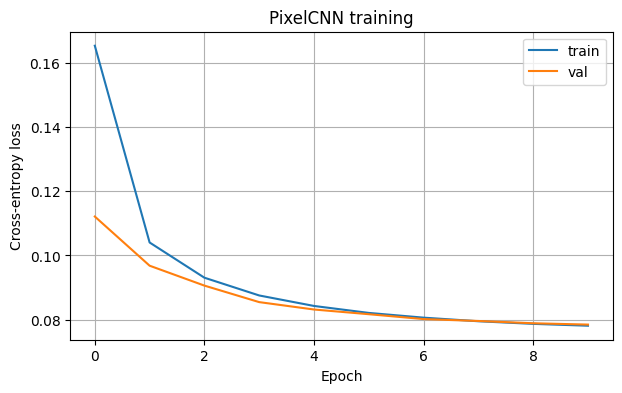


Generating samples...


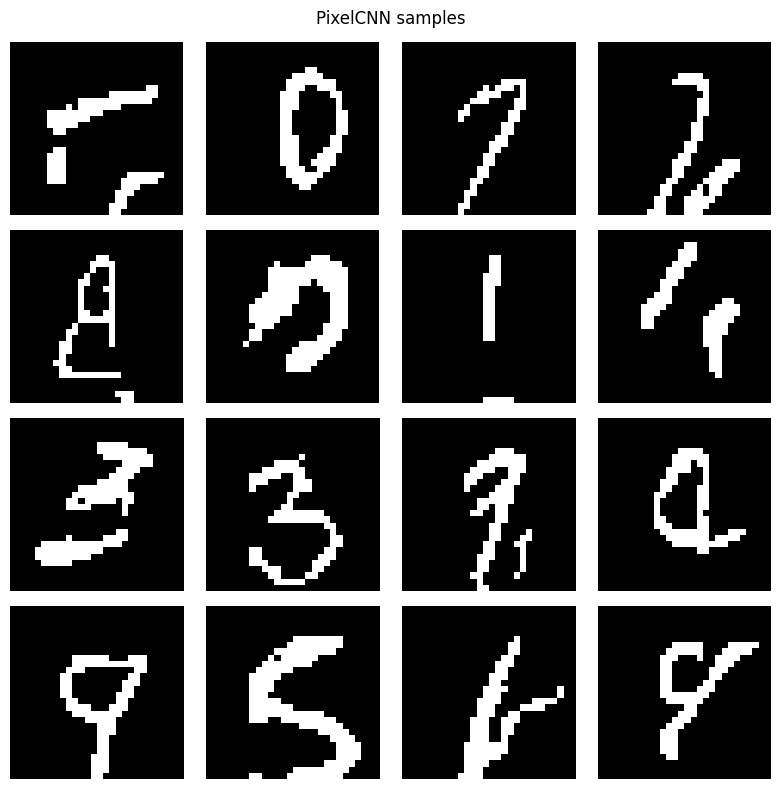

In [11]:
def run_epoch(loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_items = 0

    pbar = tqdm(loader, leave=False)
    for x, _ in pbar:
        x = x.to(DEVICE)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            loss_dict = model.loss(x)
            loss = loss_dict["total_loss"]

            if train:
                loss.backward()
                optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_items += bs

        pbar.set_description(
            f"{'train' if train else 'val'} loss: {loss.item():.4f}"
        )

    return total_loss / total_items


for epoch in range(1, epochs + 1):
    print(f"\nEpoch {epoch}/{epochs}")

    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"train_loss = {train_loss:.6f} | val_loss = {val_loss:.6f}")


plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("PixelCNN training")
plt.legend()
plt.grid(True)
plt.show()

print("\nGenerating samples...")
samples = model.sample(sample_count)   # (N, 1, 28, 28)

ncols = 4
nrows = int(np.ceil(sample_count / ncols))
plt.figure(figsize=(ncols * 2, nrows * 2))

for i in range(sample_count):
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(samples[i, 0], cmap="gray", vmin=0.0, vmax=1.0)
    plt.axis("off")

plt.suptitle("PixelCNN samples")
plt.tight_layout()
plt.show()

### 2. VAR

[Github](https://github.com/FoundationVision/VAR)

[Arxiv](https://arxiv.org/pdf/2404.02905)

![](https://github.com/FoundationVision/VAR/assets/39692511/3e12655c-37dc-4528-b923-ec6c4cfef178)


- Вместо стандартного next-token prediction используется **next-scale prediction**


*Метод:*
- Изображение представляется как иерархия масштабов (multi-scale tokens)
- Генерация происходит по уровням разрешения: от низкого (глобальная структура) к высокому (детали)
- На каждом шаге модель предсказывает весь следующий масштаб целиком, а не отдельные пиксели/токены

Визуализация обучения (скрин из статьи)

![](./assets/var-screen.jpg)

In [ ]:
## download var
# !git clone --filter=blob:none --no-checkout https://github.com/FoundationVision/VAR.git .var && cd .var && git sparse-checkout init --cone && git sparse-checkout set models && git checkout

In [ ]:
import sys

sys.path.append(".var")

In [ ]:
# code from https://github.com/FoundationVision/VAR/blob/main/demo_sample.ipynb

################## 1. Download checkpoints and build models
import os
import os.path as osp
import torch, torchvision
import random
import numpy as np
import PIL.Image as PImage, PIL.ImageDraw as PImageDraw
setattr(torch.nn.Linear, 'reset_parameters', lambda self: None)     # disable default parameter init for faster speed
setattr(torch.nn.LayerNorm, 'reset_parameters', lambda self: None)  # disable default parameter init for faster speed
from models import VQVAE, build_vae_var

MODEL_DEPTH = 16    # TODO: =====> please specify MODEL_DEPTH <=====
assert MODEL_DEPTH in {16, 20, 24, 30}


# download checkpoint
hf_home = 'https://huggingface.co/FoundationVision/var/resolve/main'
vae_ckpt, var_ckpt = 'vae_ch160v4096z32.pth', f'var_d{MODEL_DEPTH}.pth'
if not osp.exists(vae_ckpt): os.system(f'wget {hf_home}/{vae_ckpt}')
if not osp.exists(var_ckpt): os.system(f'wget {hf_home}/{var_ckpt}')

# build vae, var
patch_nums = (1, 2, 3, 4, 5, 6, 8, 10, 13, 16)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if 'vae' not in globals() or 'var' not in globals():
    vae, var = build_vae_var(
        V=4096, Cvae=32, ch=160, share_quant_resi=4,    # hard-coded VQVAE hyperparameters
        device=device, patch_nums=patch_nums,
        num_classes=1000, depth=MODEL_DEPTH, shared_aln=False,
    )

# load checkpoints
vae.load_state_dict(torch.load(vae_ckpt, map_location='cpu'), strict=True)
var.load_state_dict(torch.load(var_ckpt, map_location='cpu'), strict=True)
vae.eval(), var.eval()
for p in vae.parameters(): p.requires_grad_(False)
for p in var.parameters(): p.requires_grad_(False)
print(f'prepare finished.')


[constructor]  ==== flash_if_available=True (0/16), fused_if_available=True (fusing_add_ln=0/16, fusing_mlp=0/16) ==== 
    [VAR config ] embed_dim=1024, num_heads=16, depth=16, mlp_ratio=4.0
    [drop ratios ] drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.0666667 (tensor([0.0000, 0.0044, 0.0089, 0.0133, 0.0178, 0.0222, 0.0267, 0.0311, 0.0356,
        0.0400, 0.0444, 0.0489, 0.0533, 0.0578, 0.0622, 0.0667]))

[init_weights] VAR with init_std=0.0180422
prepare finished.


/var/folders/lv/42595jc551g9q6l8b96ktvs40000gq/T/ipykernel_49006/3341413505.py:28: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast('cuda', enabled=True, dtype=torch.float16, cache_enabled=True):    # using bfloat16 can be faster


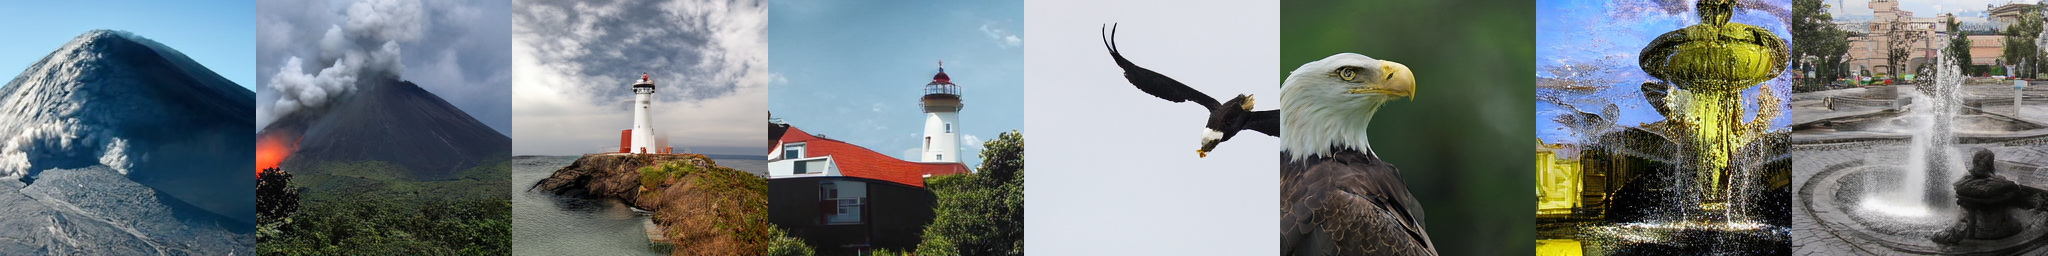

In [ ]:
############################# 2. Sample with classifier-free guidance

# set args
seed = 0 #@param {type:"number"}
torch.manual_seed(seed)
num_sampling_steps = 250 #@param {type:"slider", min:0, max:1000, step:1}
cfg = 4 #@param {type:"slider", min:1, max:10, step:0.1}
class_labels = (980, 980, 437, 437, 22, 22, 562, 562)  #@param {type:"raw"}
more_smooth = False # True for more smooth output

# seed
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# run faster
tf32 = True
torch.backends.cudnn.allow_tf32 = bool(tf32)
torch.backends.cuda.matmul.allow_tf32 = bool(tf32)
torch.set_float32_matmul_precision('high' if tf32 else 'highest')

# sample
B = len(class_labels)
label_B: torch.LongTensor = torch.tensor(class_labels, device=device)
with torch.inference_mode():
    with torch.autocast('cuda', enabled=True, dtype=torch.float16, cache_enabled=True):    # using bfloat16 can be faster
        recon_B3HW = var.autoregressive_infer_cfg(B=B, label_B=label_B, cfg=cfg, top_k=900, top_p=0.95, g_seed=seed, more_smooth=more_smooth)

    chw = torchvision.utils.make_grid(recon_B3HW, nrow=8, padding=0, pad_value=1.0)
    chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
    chw = PImage.fromarray(chw.astype(np.uint8))

chw

### 3. Switti

[Github](https://github.com/yandex-research/switti)

VAR от команды Yandex, в который 2 текстовых энкодера для text2image генерации. Сигнал энкодеров подают в трансформер с помощью cross-attention механизма. [Статья на arxiv](https://arxiv.org/pdf/2412.01819)

![](https://raw.githubusercontent.com/yandex-research/switti/refs/heads/master/assets/teaser.jpg)

In [ ]:
# %%bash

# !git clone https://github.com/yandex-research/switti.git .switti

# cat > .switti/utils/arg_util.py << 'EOF'
# RESOLUTION_PATCH_NUMS_MAPPING = {
#     256: "1_2_3_4_5_6_8_10_13_16",
#     512: "1_2_3_4_6_9_13_18_24_32",
#     1024: "1_2_3_4_5_7_9_12_16_21_27_36_48_64",
# }
# EOF

# # pip install -r .switti/requirements.txt

In [ ]:
# # one need to restart since it conflicts with var
# import sys
# sys.path.append(".switti")

# import torch

# from models import SwittiPipeline

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# model_path = "yresearch/Switti"
# dtype = torch.bfloat16 if DEVICE.type != 'cpu' else torch.float32

# pipe = SwittiPipeline.from_pretrained(model_path, device=DEVICE, torch_dtype=dtype, reso=512)

# from torchvision.utils import make_grid
# from torchvision.transforms.functional import to_pil_image

# prompts = ["Cute winter dragon baby, kawaii, Pixar, ultra detailed, glacial background, extremely realistic",
#            "flying robot koi fish with armour plating, neon glowing eyes and wiring, 4k, unreal engine, marvel comics style",
#            "sci-fi cosmic diarama of a quasar and jellyfish in a resin cube, volumetric lighting, high resolution, hdr, sharpen, Photorealism",
#            "A cloud dragon flying over mountains, its body swirling with the wind.",
#           ]
# images = pipe(prompts,
#               cfg=6.0,
#               top_k=400,
#               top_p=0.95,
#               more_smooth=True,
#               return_pil=False,
#               smooth_start_si=2,
#               turn_on_cfg_start_si=2,
#               turn_off_cfg_start_si=8,
#               last_scale_temp=0.1,
#               seed=59,
#              )
# to_pil_image(make_grid([img.float() for img in images], nrow=2))

Другие Autoregressive Модели, которые вышли за последний год

1. https://arxiv.org/pdf/2505.16324
2. https://arxiv.org/pdf/2601.22630
3. https://arxiv.org/pdf/2508.10711
4. https://github.com/FoundationVision/Infinity

## 3. Normalizing Flow

### 1. Постановка задачи. CoV

**Матрица Якоби**

Пусть задано отображение между многомерными пространствами:
$$
f: \mathbb{R}^n \to \mathbb{R}^m
$$

Матрица Якоби функции $f$ определяется как матрица частных производных:
$$
J_f(x) =
\begin{pmatrix}
\frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{pmatrix}
$$

Когда матрица Якоби квадратная (n=m) можно рассматривать её определитель:
$$
\det J_f(x)
$$

геометрический смысл:

* он показывает, **во сколько раз локально изменяется объём** при преобразовании $f$
* знак определяет ориентацию
* абсолютное значение коэффициент масштабирования


**Теорема замены переменных: Change of Variables Theorem (CoV)**

* $x \sim p_X(x)$
* $z = f(x)$, где $f$ биективное и дифференцируемое отображение

Тогда плотность распределения $z$ выражается как:
$$
p_Z(z) = p_X(f^{-1}(z)) \cdot \left| \det J_{f^{-1}}(z) \right|
$$

Эквивалентная форма:
$$
p_X(x) = p_Z(f(x)) \cdot \left| \det J_f(x) \right|
$$

Дополнительно:

$$\left| \det J_{f^{-1}} \right| = \left| \det {J_{f}}^{-1} \right| = \frac{1}{\left| \det {J_{f}} \right|}$$

<img src="./assets/jac.png" width="300">

**MLE Problem**

$$
p_X(x | \theta) = p_Z(f_\theta(x)) \cdot \left| \det J_{f_{\theta}}(x) \right|
$$

$$
log p(x | \theta) = log p(f_\theta(x)) +  log \left| \det J_{f_{\theta}}(x) \right| \rightarrow \max_{\theta}

$$

<img src="./assets/nf.png" width="1000">


Теперь, если мы можем разложить функцию преобразования на композицию "хороших" функций, то есть

$z = f(x) = f_K \circ\dots\circ f_1(x)$

CoV раскладывается на произведение (бд)

$$
p(x) = p(f(x)) \cdot |\det J(f(x))| = \dots = p(f(x)) \prod_{k=1}^K{|\det J(f_k(x))|}
$$

<img src="./assets/nf-comp.png" width="900">

Собрав все вместе, получаем формулу для вычисления MLE:

$$
log p(x | \theta) = log p(f_\theta(x)) + \sum_{k=1}^K{log|\det J(f_{\theta_k}(x))|}
$$

---

**Normalizing Flows: pros and cons**



**pros**
- 1. Точное вычисление likelihood
- 2. Обратимость

  Это даёт:
  * генерацию: $z \to x$
  * inference: $x \to z$

- 3. Стабильное обучение
  * Просто MLE оптимизация (без proxy)

- 4. Интерпретируемость

**cons**

- 1. Ограничения на архитектуру

  нужна
  * обратимость
  * вычислимый якобиан
- 2. Вычисление детерминанта

  * в общем случае $O(n^3)$
  * приходится проектировать архитектуру так, чтобы:
    * якобиан был треугольным или простым

- 3. Плохая масштабируемость в высоких размерностях
- 4. Часто хуже по качеству генерации
  
  По сравнению с:
  * diffusion models
  * GAN
- 5. Требование биективности

### 2. Примеры NF

#### Linear Normalizing Flow 

Рассмотрим самый простой класс нормализующих потоков — **линейные normalizing flows**

В случае **linear flow** функция $f$ задаётся как:

$$
x = f(z) = Az + b
$$

где:

* $A \in \mathbb{R}^{n \times n}$ невырожденная матрица
* $b \in \mathbb{R}^n$ вектор сдвига

обычное аффинное преобразование


Так как $A$ невырождена, существует обратная матрица:

$$
z = A^{-1}(x - b)
$$

Для линейного преобразования якобиан имеет простой вид:

$$
J_f(z) = A
$$

Он не зависит от $z$ поэтому:

$$
\det J_f(z) = \det A
$$

Плотность распределения

$$
\log p_X(x) = \log p_Z(A^{-1}(x - b)) - \log |\det A|
$$

**Проблемы**

- Вычисление детерминанта
   * Требуется считать $\det A$
   * В общем случае: $O(n^3)$

- Обращение матрицы
   * Нужно для перехода $x \to z$
   * Стоимость: $O(n^3)$

- Плохая масштабируемость

Эти проблемы можно стараться решать, упрощая матрицы (диагональные, треугольные, ортогональные, LU, QR разложения)


#### Real NVP



**RealNVP (Real-valued Non-Volume Preserving)**

[arxiv](https://arxiv.org/abs/1605.08803)

* строит сложное распределение через композицию простых преобразований
* сохраняет обратимость
* делает вычисление якобиана дешёвым


- **1. Coupling layer**

Пусть вход:
$$
x = (x_1, x_2)
$$

Coupling layer делает:

$$
y_1 = x_1
$$
$$
y_2 = x_2 \odot \exp(s(x_1)) + t(x_1)
$$

где:

* $s(\cdot)$ scale network
* $t(\cdot)$ translation network

- **2. Якобиан**

Матрица якоби получается *треугольной*:

$$
J =
\begin{pmatrix}
I & 0 \\

* & \text{diag}(\exp(s(x_1)))
  \end{pmatrix}
$$

Поэтому:

$$
\log |\det J| = \sum s(x_1)
$$

* детерминант считается за ( O(n) )

- **3. Обратное преобразование**

$$
x_1 = y_1
$$
$$
x_2 = (y_2 - t(y_1)) \odot \exp(-s(y_1))
$$

- **4. Полная модель**

$$
z = f(x) = f_K \circ \dots \circ f_1(x)
$$

между слоями:

* меняется маска
* перемешиваются координаты

<img src="assets/realnvp.png" width="500">

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import MultivariateNormal


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def make_moons_data(n_samples=2000, noise=0.06):
    x, _ = make_moons(n_samples=n_samples, noise=noise, random_state=SEED)
    x = x.astype(np.float32)

    x = x - x.mean(axis=0, keepdims=True)
    x = x / x.std(axis=0, keepdims=True)

    return torch.tensor(x, dtype=torch.float32)


class STNet(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class AffineCoupling(nn.Module):
    def __init__(self, mask, hidden_dim=128):
        super().__init__()
        # If mask = [1, 0]:
        #   x1 stays unchanged
        #   x2 transformed using x1
        self.register_buffer("mask", torch.tensor(mask, dtype=torch.float32))
        self.s_net = STNet(in_dim=2, hidden_dim=hidden_dim, out_dim=2)
        self.t_net = STNet(in_dim=2, hidden_dim=hidden_dim, out_dim=2)

    def forward(self, x):
        """
        y1 = x1
        y2 = x2 * exp(s(x1)) + t(x1)
        
        Returns:
            y, log_det
        """
        x_masked = x * self.mask

        s = pass
        t = pass

        # Ограничиваем scale для стабильности
        s = torch.tanh(s)

        y = pass

        log_det = pass

        return y, log_det

    def inverse(self, y):
        """
        z -> x
        Inverse transformation
        """
        y_masked = y * self.mask

        s = pass
        t = pass

        s = torch.tanh(s)

        x = pass
        return x


class RealNVP2D(nn.Module):
    def __init__(self, n_coupling_layers=8, hidden_dim=128):
        super().__init__()

        layers = []
        for i in range(n_coupling_layers):
            if i % 2 == 0:
                mask = [1.0, 0.0]
            else:
                mask = [0.0, 1.0]
            layers.append(AffineCoupling(mask=mask, hidden_dim=hidden_dim))

        self.layers = nn.ModuleList(layers)

        self.base_dist = MultivariateNormal(
            loc=torch.zeros(2, device=device),
            covariance_matrix=torch.eye(2, device=device),
        )

    def forward(self, x):
        """
        Data x -> latent z
        Returns:
            z, sum_log_det
        """
        log_det_sum = torch.zeros(x.shape[0], device=x.device)
        z = x

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_sum += log_det

        return z, log_det_sum

    def inverse(self, z):
        """
        Latent z -> data x
        """
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x

    def log_prob(self, x):
        pass

    @torch.no_grad()
    def sample(self, n_samples):
        pass

Epoch    1 | NLL = 3.186412
Epoch  100 | NLL = 2.114232
Epoch  200 | NLL = 1.914322
Epoch  300 | NLL = 1.666016
Epoch  400 | NLL = 1.819438
Epoch  500 | NLL = 1.655387
Epoch  600 | NLL = 1.688758
Epoch  700 | NLL = 1.689538
Epoch  800 | NLL = 1.731424
Epoch  900 | NLL = 1.650535
Epoch 1000 | NLL = 1.738267
Epoch 1100 | NLL = 1.664291
Epoch 1200 | NLL = 1.662562
Epoch 1300 | NLL = 1.604843
Epoch 1400 | NLL = 1.642161
Epoch 1500 | NLL = 1.682763
Epoch 1600 | NLL = 1.717694
Epoch 1700 | NLL = 1.656873
Epoch 1800 | NLL = 1.689358
Epoch 1900 | NLL = 1.564628
Epoch 2000 | NLL = 1.715149


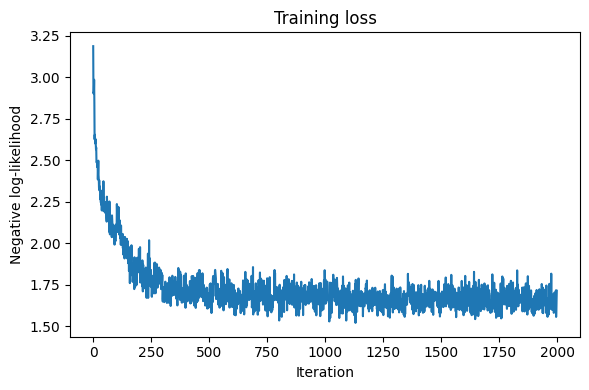

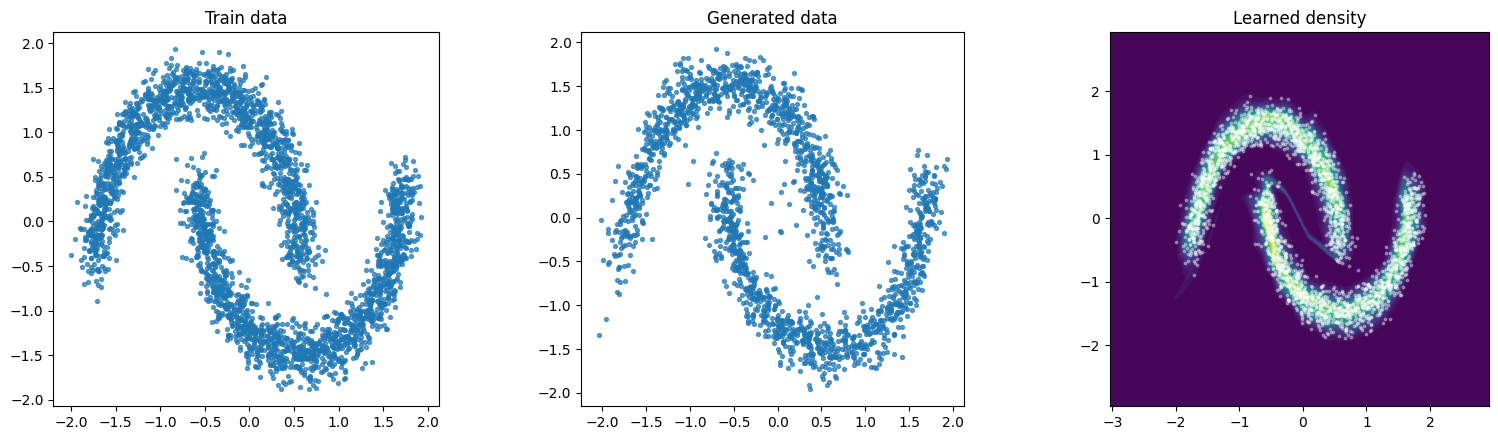

In [ ]:
@torch.no_grad()
def plot_results(model, train_data, n_generated=2000, grid_points=300):
    model.eval()

    train_np = train_data.cpu().numpy()
    generated = model.sample(n_generated).cpu().numpy()

    all_x = np.concatenate([train_np[:, 0], generated[:, 0]])
    all_y = np.concatenate([train_np[:, 1], generated[:, 1]])

    x_min, x_max = all_x.min() - 1.0, all_x.max() + 1.0
    y_min, y_max = all_y.min() - 1.0, all_y.max() + 1.0

    xs = np.linspace(x_min, x_max, grid_points)
    ys = np.linspace(y_min, y_max, grid_points)
    xx, yy = np.meshgrid(xs, ys)

    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)
    grid_t = torch.tensor(grid, device=device)

    log_prob = model.log_prob(grid_t).cpu().numpy()
    density = np.exp(log_prob).reshape(xx.shape)

    _, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].scatter(train_np[:, 0], train_np[:, 1], s=8, alpha=0.7)
    axes[0].set_title("Train data")
    axes[0].set_aspect("equal")

    axes[1].scatter(generated[:, 0], generated[:, 1], s=8, alpha=0.7)
    axes[1].set_title("Generated data")
    axes[1].set_aspect("equal")

    axes[2].contourf(xx, yy, density, levels=40)
    axes[2].scatter(train_np[:, 0], train_np[:, 1], s=3, c="white", alpha=0.35)
    axes[2].set_title("Learned density")
    axes[2].set_aspect("equal")

    plt.tight_layout()
    plt.show()


def train_real_nvp():
    n_samples = 3000
    noise = 0.08
    batch_size = 256
    n_epochs = 2000
    lr = 1e-3
    log_every = 100

    train_data = make_moons_data(n_samples=n_samples, noise=noise).to(device)

    model = RealNVP2D(
        n_coupling_layers=10,
        hidden_dim=128,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(1, n_epochs + 1):
        model.train()

        indices = torch.randint(0, train_data.shape[0], (batch_size,), device=device)
        batch = train_data[indices]

        log_prob = model.log_prob(batch)
        loss = -log_prob.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % log_every == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | NLL = {loss.item():.6f}")

    plt.figure(figsize=(6, 4))
    plt.plot(losses)
    plt.title("Training loss")
    plt.xlabel("Iteration")
    plt.ylabel("Negative log-likelihood")
    plt.tight_layout()
    plt.show()

    plot_results(model, train_data)


train_real_nvp()

### 3. CNF (Continuous Normalizing Flow)



В обычных normalizing flows мы применяем **дискретную последовательность преобразований**:

<img src="assets/cnf.png" width="500">

$$
z_K = f_K \circ \dots \circ f_1(z_0)
$$

А в **Continuous Normalizing Flow** мы делаем переход к **непрерывному времени**:

$$
\frac{dz(t)}{dt} = f(z(t), t)
$$

Плотность выглядит как (*continuity equation*):

$$
\frac{d}{dt} \log p(z(t)) = - \mathrm{Tr} \left( \frac{\partial f}{\partial z} \right)
$$

Положим $p_0$ - простое распределение, $p_1$ - распределение данных

*Continuity equation solution:*

$$
\log p_1(x) = \log p_0(z) - \int_{0}^{1} \text{tr}  \left( \frac{\partial f(x(t), t)}{\partial x(t)} \right) dt.
$$

Для решения используют довольно сложные и не очень стабильные методы. Один из таких **adjoint method** ([Neural ODE](https://arxiv.org/abs/1806.07366))


---


#### Flow Matching

[Arxiv](https://arxiv.org/pdf/2210.02747)

[blogpost](https://mlg.eng.cam.ac.uk/blog/2024/01/20/flow-matching.html) 

Flow Matching можно рассматривать как альтернативный способ обучения Continuous Normalizing Flows без использования likelihood

**Flow Matching** — это метод обучения непрерывных генеративных моделей, в которых данные генерируются через динамику, заданную дифференциальным уравнением.

Рассматривается динамическая система:
$$\frac{dx}{dt} = v_\theta(x, t)$$
где:

* $v_\theta(x, t)$ — параметризованное векторное поле
* $x(t)$ — траектория точки во времени

**Процесс обучения**

Пусть:

* $x_0 \sim p_0$ — простое распределение (например, $\mathcal{N}(0, I)$ )
* $x_1 \sim p_{\text{data}}$  данные

Определим траекторию $x_t$ между ними

Модель обучается минимизацией:

$$
\mathcal{L}(\theta) = \mathbb{E}_{t, x_0, x_1} \left[ \left| v_\theta(x_t, t) - v^*(x_t, t) \right|^2 \right]
$$

---

#### Rectified Flow

[rectified flow blogpost ](https://rectifiedflow.github.io/)

это частный случай Flow Matching с особым выбором траекторий

Выбирается **прямая траектория** между шумом и данными:

$$
x_t = (1 - t)x_0 + t x_1
$$

$$
v^*(x_t, t) = x_1 - x_0
$$

Получаем
$$
\mathcal{L}(\theta) = \mathbb{E} \left[ | v_\theta(x_t, t) - (x_1 - x_0) |^2 \right]
$$


[Flux2](https://github.com/black-forest-labs/flux2/tree/main) - один из примеров rectified flow трансформера

![](https://github.com/black-forest-labs/flux2/raw/refs/heads/main/assets/teaser_generation.png)